In [1]:
import datetime as dt
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from string import ascii_letters
rs = np.random.RandomState(33)
d = pd.DataFrame(data=rs.normal(size=(100, 26)),
                 columns=list(ascii_letters[26:]))
corr = d.corr()
corr.head()

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
A,1.000000,-0.107401,-0.086468,0.000131,0.035047,0.004749,0.028226,0.000422,0.132100,0.057720,...,0.073645,-0.055396,-0.058241,-0.123823,0.096451,-0.015178,0.172725,0.003791,0.005531,-0.011534
B,-0.107401,1.000000,0.254632,0.061506,0.043581,-0.078019,0.069133,-0.211278,-0.011796,0.085277,...,0.031315,0.100451,-0.103068,0.011187,-0.008536,-0.030730,-0.022978,-0.050483,-0.014468,0.078737
C,-0.086468,0.254632,1.000000,-0.033682,-0.127464,0.141223,0.164793,-0.188574,-0.230059,0.145777,...,0.010497,0.051872,0.084793,0.167976,-0.043806,-0.057125,0.125580,-0.068426,-0.052764,0.094661
D,0.000131,0.061506,-0.033682,1.000000,0.086054,-0.153212,-0.000963,-0.017282,-0.109283,0.011056,...,-0.136959,-0.061816,0.134112,0.081143,0.124706,0.194911,-0.016944,-0.116963,0.054315,0.014383
E,0.035047,0.043581,-0.127464,0.086054,1.000000,-0.007159,0.157224,-0.096254,0.043785,0.015117,...,0.090499,0.041276,0.076138,0.027021,0.069976,-0.021745,0.104822,-0.047913,0.120465,0.080980


In [3]:
infile = "./Activities.csv"
if not os.path.exists(infile):
    raise Exception(f"{infile} does not exist")
activities_types = {
    'Activity Type': str,
    'Date': np.datetime64,
    'Title': str,
    'Time': np.datetime64,
    'Avg Pace': np.datetime64,
    'Best Pace': np.datetime64,
    'Best Lap Time': np.datetime64,
    'Moving Time': np.datetime64,
    'Elapsed Time': np.datetime64,
}
df = pd.read_csv(infile, header=0, parse_dates=[0, 1, 6, 7])
# print(df.dtypes)
df

/tmp/ipykernel_17917/2850027999.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(infile, header=0, parse_dates=[0, 1, 6, 7])
/tmp/ipykernel_17917/2850027999.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(infile, header=0, parse_dates=[0, 1, 6, 7])


,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Avg Run Cadence,...,Avg Stride Length,Training Stress Score®,Steps,Decompression,Best Lap Time,Number of Laps,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Running,2025-12-31 16:01:35,False,Fairfax County Running,3.21,373,2026-02-22 00:28:53,152,164,168,...,1.07,0.0,"4,842",No,00:01:42.7,4,00:28:42,00:28:53,8,99
1,Running,2025-12-28 09:32:35,False,Fairfax County Running,9.43,"1,170",2026-02-22 01:29:54,164,187,173,...,0.98,0.0,"15,568",No,00:04:25.2,10,01:29:51,01:29:54,3,99
2,Running,2025-12-26 08:43:25,False,Fairfax County Running,3.71,451,2026-02-22 00:34:09,152,178,170,...,1.03,0.0,"5,790",No,00:06:29.6,4,00:34:08,00:34:09,10,99
3,Running,2025-12-24 09:40:43,False,Fairfax County Running,4.23,506,2026-02-22 00:38:57,153,178,169,...,1.04,0.0,"6,570",No,00:02:28.2,5,00:38:49,00:40:22,4,99
4,Running,2025-12-23 16:33:23,False,Fairfax County Running,3.01,333,2026-02-22 00:27:25,142,158,167,...,1.05,0.0,"4,608",No,00:00:03.4,4,00:27:20,00:27:25,50,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Running,2025-01-12 10:16:11,False,Fairfax County Running,5.07,624,2026-02-22 00:48:15,154,172,166,...,1.02,0.0,"8,068",No,00:00:43.6,6,00:47:45,00:53:40,3,99
153,Running,2025-01-11 08:29:26,False,Fairfax County Running,4.12,517,2026-02-22 00:40:39,154,172,167,...,0.97,0.0,"6,816",No,00:01:41.3,5,00:40:09,00:40:39,15,98
154,Running,2025-01-07 08:20:27,False,Fairfax County Running,3.00,371,2026-02-22 00:28:39,159,173,165,...,1.02,0.0,"4,732",No,00:00:03.5,4,00:28:38,00:28:39,49,99
155,Running,2025-01-05 10:24:19,False,Fairfax County Running,3.16,384,2026-02-22 00:29:05,164,182,167,...,1.05,0.0,"4,854",No,00:01:36.8,4,00:29:04,00:29:05,9,99


In [4]:
running_df = df[['Date', 'Distance', 'Time']]
dow = running_df.Date.dt.day_of_week
running_df.loc[:,'dow'] = dow
running_df['weeknum'] = 1
running_df.loc[:,'weeknum'] = running_df.Date.dt.isocalendar().week
running_df.loc[( (running_df.Date.dt.month == 12) & ( running_df.Date.dt.day == 31)), 'weeknum'] = 53
running_df.head()

,Date,Distance,Time,dow,weeknum
0,2025-12-31 16:01:35,3.21,2026-02-22 00:28:53,2,53
1,2025-12-28 09:32:35,9.43,2026-02-22 01:29:54,6,52
2,2025-12-26 08:43:25,3.71,2026-02-22 00:34:09,4,52
3,2025-12-24 09:40:43,4.23,2026-02-22 00:38:57,2,52
4,2025-12-23 16:33:23,3.01,2026-02-22 00:27:25,1,52


In [5]:
# running_df['dow'] = running_df.Date.dt.day_of_week
# running_df.head()
piv = running_df.pivot_table(index='dow', columns='weeknum', values='Distance', aggfunc='sum', fill_value=0)

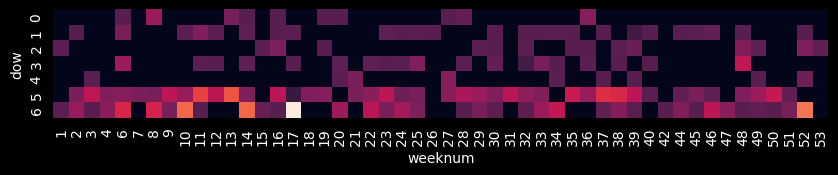

In [6]:
plt.figure(figsize=(10,10))
ax = sns.heatmap(piv, square=True, linewidths=0, cbar=False)

